# Identifying Malicious URLs (PyTorch)

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

In [12]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

## 1. Data Loading

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [14]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    padded = start_symbol * (n - 1) + text + end_symbol * n
    return (padded[i:i+n] for i in range(len(padded) - n + 1))

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [15]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        if count >= rare_threshold:
            n2i[ngram] = len(i2n)
            i2n.append(ngram)
        else:
            n_rare += 1

    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 30467.10it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 174762.67it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [16]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))

    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            idx = n2i_mapping.get(ngram, unknown_idx)

            for prev_idx in prev_indices[-window_size:]:
                co_matrix[idx, prev_idx] = co_matrix.get((idx, prev_idx), 0) + 1
                co_matrix[prev_idx, idx] = co_matrix.get((prev_idx, idx), 0) + 1

            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    for (i, j) in tqdm(list(co_matrix.keys())):
        if row_sums[i, 0] > 0:
            co_matrix[i, j] = co_matrix[i, j] / row_sums[i, 0]

    return co_matrix

In [17]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:03<00:00, 11682.20it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 1042714.62it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [06:26<00:00, 93.95it/s] 


Normalizing...


100%|██████████| 2542234/2542234 [01:13<00:00, 34390.68it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [18]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [20]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        url = url[:padded_len].ljust(padded_len, pad_symbol)

        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [21]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [22]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_weights, dtype=torch.float32),
            freeze=True
        )

        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x)).squeeze(1)
        return x

In [23]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [24]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [25]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.6985, Val Acc=0.8758
Epoch 2: Train Acc=0.8843, Val Acc=0.8898
Epoch 3: Train Acc=0.9060, Val Acc=0.9189
Epoch 4: Train Acc=0.9097, Val Acc=0.9061
Epoch 5: Train Acc=0.9148, Val Acc=0.9217
Epoch 6: Train Acc=0.9195, Val Acc=0.9287
Epoch 7: Train Acc=0.9264, Val Acc=0.9266
Epoch 8: Train Acc=0.9281, Val Acc=0.9346
Epoch 9: Train Acc=0.9309, Val Acc=0.9341
Epoch 10: Train Acc=0.9351, Val Acc=0.9239


## 6. Evaluation

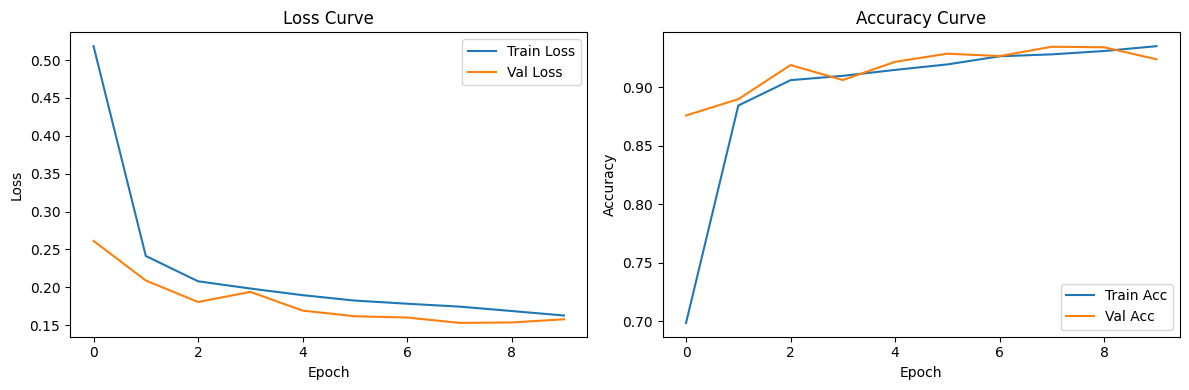

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x).cpu().numpy()
        y_pred.extend((out > 0.5).astype(int))
        y_true.extend(y.numpy().astype(int))

print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
[[6952  191]
 [ 728 4239]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9052    0.9733    0.9380      7143
           1     0.9569    0.8534    0.9022      4967

    accuracy                         0.9241     12110
   macro avg     0.9310    0.9133    0.9201     12110
weighted avg     0.9264    0.9241    0.9233     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

## Your Answer:
Generally speaking, yes, lower loss does indicate higher accuracy. For this model, the trend clearly shows that decreasing loss directly corresponds to increasing accuracy, which is the desired behavior during training.

**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

## Your Answer:

A large window size may help with capturing a wider range of signals, patterns, and feature relationships, yet it would also increase the chance of picking up noises.

Other compression methods include PCA, KPCA, and Autoencoders, among many others, each with their own pros and cons.